# Medical VQA — BLIP Captioning (Open-Ended)

This notebook handles the open-ended captioning branch of the Medical VQA pipeline.
It uses BLIP (Bootstrapping Language-Image Pre-training) to generate free-form medical descriptions.

**Two stages:**
1. Zero-shot BLIP — no training, immediate baseline results
2. Fine-tuned BLIP — frozen vision encoder, fine-tuned language head only

**Dataset:** ROCO subset of robailleo/medical-vision-llm-dataset (~3,000 open-ended samples)

## 1. Install Dependencies

In [ ]:
!pip install -q datasets transformers torch torchvision pillow evaluate rouge_score bert_score

## 2. Imports

In [1]:
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from datasets import load_dataset
from transformers import BlipProcessor, BlipForConditionalGeneration

import evaluate

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

c:\Users\Micah\Documents\code\Medical_VQA_Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 17.1 GB


## 4. Save Directory

In [2]:
SAVE_DIR = './checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Save directory ready:', SAVE_DIR)

Save directory ready: ./checkpoints


## 5. Utility Functions

In [3]:
def open_image_from_dataset_value(image_value):
    """Opens an image from different possible HuggingFace/pandas formats."""
    if isinstance(image_value, Image.Image):
        return image_value
    if isinstance(image_value, dict) and image_value.get('bytes') is not None:
        return Image.open(io.BytesIO(image_value['bytes']))
    if isinstance(image_value, dict) and image_value.get('path') is not None:
        return Image.open(image_value['path'])
    return None


def normalize_text(x):
    """Cleans text by converting to lowercase and stripping whitespace."""
    if x is None:
        return None
    return str(x).strip().lower()


def infer_question_type(answer):
    """Classifies answer as binary (yes/no) or open-ended."""
    ans = normalize_text(answer)
    if ans in {'yes', 'no'}:
        return 'binary'
    return 'open_ended'


print('Utilities ready!')

Utilities ready!


## 6. Load Dataset and Filter ROCO Subset

In [4]:
# Load from HuggingFace
dataset = load_dataset('robailleo/medical-vision-llm-dataset')

# Convert to DataFrames
train_df = dataset['train'].to_pandas()
val_df   = dataset['validation'].to_pandas()

# Add question type column
train_df['question_type'] = train_df['answer'].apply(infer_question_type)
val_df['question_type']   = val_df['answer'].apply(infer_question_type)

# Filter to open-ended (ROCO) only
train_roco = train_df[train_df['question_type'] == 'open_ended'].reset_index(drop=True)
val_roco   = val_df[val_df['question_type'] == 'open_ended'].reset_index(drop=True)

print('Open-ended train size:', len(train_roco))
print('Open-ended val size:  ', len(val_roco))
print('\nSample question:', train_roco['question'].iloc[0])
print('Sample answer:  ', train_roco['answer'].iloc[0])

Open-ended train size: 3084
Open-ended val size:   769

Sample question: Describe the medical findings in this image.
Sample answer:   Axial CT chest showing multiple pulmonary nodules in the right upper lobe. Black arrow pointing to RUL nodules


## 7. Load BLIP Model and Processor

In [5]:
MODEL_NAME = 'Salesforce/blip-image-captioning-base'

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model     = model.to(device)

print('BLIP model loaded!')
print('Total params:     ', sum(p.numel() for p in model.parameters()))
print('Trainable params: ', sum(p.numel() for p in model.parameters() if p.requires_grad))

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 52835.12it/s]


BLIP model loaded!
Total params:      223971644
Trainable params:  223971644


## 8. Evaluation Metrics Setup

In [6]:
bleu  = evaluate.load('bleu')
rouge = evaluate.load('rouge')

def compute_captioning_metrics(predictions, references):
    """
    Computes BLEU and ROUGE scores.
    predictions: list of generated strings
    references:  list of ground truth strings
    """
    # BLEU expects references as list of lists
    bleu_refs  = [[ref] for ref in references]
    bleu_score = bleu.compute(predictions=predictions, references=bleu_refs)

    rouge_score = rouge.compute(predictions=predictions, references=references)

    return {
        'bleu':    round(bleu_score['bleu'], 4),
        'rouge1':  round(rouge_score['rouge1'], 4),
        'rouge2':  round(rouge_score['rouge2'], 4),
        'rougeL':  round(rouge_score['rougeL'], 4),
    }


def print_captioning_metrics(metrics, model_name='Model'):
    # print(f"\n{'='*40}")
    print(f'  {model_name} /n')
    # print(f"{'='*40}")
    print(f"  BLEU   : {metrics['bleu']:.4f}")
    print(f"  ROUGE-1: {metrics['rouge1']:.4f}")
    print(f"  ROUGE-2: {metrics['rouge2']:.4f}")
    print(f"  ROUGE-L: {metrics['rougeL']:.4f}")
    # print(f"{'='*40}\n")


print('Metrics ready!')

Metrics ready!


---
# STAGE 1 — Zero-Shot BLIP
Run BLIP out of the box with no training. This gives us an immediate baseline and results to write about before fine-tuning finishes.

## 9. Zero-Shot Inference

In [20]:
def run_zero_shot(df, processor, model, device, max_new_tokens=100, sample_n=None):
    """
    Runs zero-shot BLIP captioning on a dataframe.
    If sample_n is set, only runs on a subset (useful for quick testing).
    """
    model.eval()

    if sample_n:
        df = df.sample(n=sample_n, random_state=RANDOM_STATE).reset_index(drop=True)

    predictions = []
    references  = []

    for idx, row in df.iterrows():
        img = open_image_from_dataset_value(row['image'])
        if img is None:
            continue

        img = img.convert('RGB')

        # Use the question as the text prompt
        inputs = processor(
            images=img,
            # text=str(row['question']),
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
            )

        generated = processor.decode(output_ids[0], skip_special_tokens=True)

        predictions.append(generated)
        references.append(str(row['answer']))

        if idx % 50 == 0:
            print(f'  [{idx}/{len(df)}] done')

    return predictions, references


print('Zero-shot function ready!')

Zero-shot function ready!


In [9]:
# Quick sanity check on 5 samples first
print('Running sanity check on 5 samples...')
sample_preds, sample_refs = run_zero_shot(val_roco, processor, model, device, sample_n=5)

for i, (pred, ref) in enumerate(zip(sample_preds, sample_refs)):
    print(f'\n--- Sample {i+1} ---')
    print(f'Generated: {pred}')
    print(f'Reference: {ref}')

Running sanity check on 5 samples...
  [0/5] done

--- Sample 1 ---
Generated: where is the mass located? mri radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radio
Reference: suprasellar

--- Sample 2 ---
Generated: describe the medical findings in this image. medical, medical imaging, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology, radiology
Reference: MR arthrography, sagittal oblique T1-weighted image. In a patient with adhesive capsulitis for 15 weeks, the fat triangle (arrowheads) signal is considerably reduced

--- Sample 3 ---
Generated: describe the medical findings in this image., texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas, texas,

In [10]:
# Full zero-shot evaluation on validation set (~15-20 min)
print('Running full zero-shot evaluation on validation set...')
print('This will take ~15-20 minutes on your 5070 Ti\n')

zeroshot_preds, zeroshot_refs = run_zero_shot(val_roco, processor, model, device)

metrics_zeroshot = compute_captioning_metrics(zeroshot_preds, zeroshot_refs)
print_captioning_metrics(metrics_zeroshot, model_name='BLIP Zero-Shot')

Running full zero-shot evaluation on validation set...
This will take ~15-20 minutes on your 5070 Ti

  [0/769] done
  [50/769] done
  [100/769] done
  [150/769] done
  [200/769] done
  [250/769] done
  [300/769] done
  [350/769] done
  [400/769] done
  [450/769] done
  [500/769] done
  [550/769] done
  [600/769] done
  [650/769] done
  [700/769] done
  [750/769] done

  BLIP Zero-Shot
  BLEU   : 0.0000
  ROUGE-1: 0.0518
  ROUGE-2: 0.0034
  ROUGE-L: 0.0427



In [11]:
# Save zero-shot predictions for later comparison
zeroshot_df = pd.DataFrame({
    'reference':  zeroshot_refs,
    'zero_shot':  zeroshot_preds,
})
zeroshot_df.to_csv('blip_zeroshot_predictions.csv', index=False)
print('Zero-shot predictions saved!')

Zero-shot predictions saved!


---
# STAGE 2 — Fine-Tuned BLIP
Fine-tune BLIP with the vision encoder frozen and only the language decoder updated.
This is the scientifically correct choice given our small dataset size (~3,000 samples)
and avoids overfitting the vision encoder.

## 10. Freeze Vision Encoder

In [7]:
# Reload a fresh BLIP for fine-tuning
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

# Freeze the vision encoder entirely
for param in model.vision_model.parameters():
    param.requires_grad = False

# Only the text decoder is trainable
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print(f'Frozen params:    {total_params - trainable_params:,}')
print(f'Trainable %:      {100 * trainable_params / total_params:.1f}%')

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 66632.16it/s]


Total params:     223,971,644
Trainable params: 137,881,148
Frozen params:    86,090,496
Trainable %:      61.6%


## 11. PyTorch Dataset for Fine-Tuning

In [8]:
class BLIPCaptioningDataset(Dataset):
    """
    PyTorch Dataset for BLIP fine-tuning on open-ended captioning.
    Returns processor-encoded inputs with labels for language modeling loss.
    """
    def __init__(self, dataframe, processor, max_length=128):
        self.dataframe  = dataframe.reset_index(drop=True)
        self.processor  = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img = open_image_from_dataset_value(row['image'])
        if img is None:
            raise ValueError(f'Could not open image at index {idx}')
        img = img.convert('RGB')

        # Encode image + question as input, answer as target
        encoding = self.processor(
            images=img,
            text=str(row['question']),
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Encode the answer (caption) as labels
        labels = self.processor.tokenizer(
            str(row['answer']),
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        ).input_ids

        # Replace padding token id with -100 so loss ignores padding
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            'pixel_values': encoding['pixel_values'].squeeze(0),
            'input_ids':    encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':       labels.squeeze(0),
        }


print('BLIPCaptioningDataset ready!')

BLIPCaptioningDataset ready!


In [9]:
train_dataset = BLIPCaptioningDataset(train_roco, processor)
val_dataset   = BLIPCaptioningDataset(val_roco, processor)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

print('Train batches:', len(train_loader))
print('Val batches:  ', len(val_loader))

Train batches: 386
Val batches:   97


## 12. Fine-Tuning Loop

In [10]:
def fine_tune_blip(model, train_loader, val_loader, processor, device,
                   epochs=15, patience=3, lr=5e-5):

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )
    scheduler = ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-7
    )

    best_val_loss    = float('inf')
    patience_counter = 0
    save_path        = os.path.join(SAVE_DIR, 'blip_finetuned_best.pth')
    history          = []

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss  = 0.0
        train_steps = 0

        for batch in train_loader:
            pixel_values   = batch['pixel_values'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()

            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss  += loss.item()
            train_steps += 1

        # --- Validation ---
        model.eval()
        val_loss  = 0.0
        val_steps = 0

        with torch.no_grad():
            for batch in val_loader:
                pixel_values   = batch['pixel_values'].to(device)
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)

                outputs = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                val_loss  += outputs.loss.item()
                val_steps += 1

        avg_train_loss = train_loss / train_steps
        avg_val_loss   = val_loss / val_steps

        scheduler.step(avg_val_loss)
        lr_current = optimizer.param_groups[0]['lr']

        print(f'Epoch [{epoch+1:02d}/{epochs}] '
              f'Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | '
              f'LR: {lr_current:.2e}')

        history.append({
            'epoch':      epoch + 1,
            'train_loss': avg_train_loss,
            'val_loss':   avg_val_loss,
        })

        if avg_val_loss < best_val_loss:
            best_val_loss    = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f'  ✓ Best model saved (Val Loss: {avg_val_loss:.4f})')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}.')
                break

    print(f'\nBest Val Loss: {best_val_loss:.4f}')
    return save_path, pd.DataFrame(history)


print('Fine-tuning function ready!')

Fine-tuning function ready!


In [11]:
# Run fine-tuning (~45-90 min on 5070 Ti with frozen vision encoder)
torch.manual_seed(RANDOM_STATE)
save_path, history_df = fine_tune_blip(
    model, train_loader, val_loader, processor, device,
    epochs=15, patience=3, lr=5e-5
)

Epoch [01/15] Train Loss: 6.6332 | Val Loss: 6.2765 | LR: 5.00e-05
  ✓ Best model saved (Val Loss: 6.2765)
Epoch [02/15] Train Loss: 6.1415 | Val Loss: 6.1770 | LR: 5.00e-05
  ✓ Best model saved (Val Loss: 6.1770)
Epoch [03/15] Train Loss: 5.9102 | Val Loss: 6.1602 | LR: 5.00e-05
  ✓ Best model saved (Val Loss: 6.1602)
Epoch [04/15] Train Loss: 5.6371 | Val Loss: 6.1825 | LR: 5.00e-05
Epoch [05/15] Train Loss: 5.3206 | Val Loss: 6.2309 | LR: 5.00e-05
Epoch [06/15] Train Loss: 4.9626 | Val Loss: 6.3534 | LR: 2.50e-05

Early stopping at epoch 6.

Best Val Loss: 6.1602


## 13. Training Loss Curve

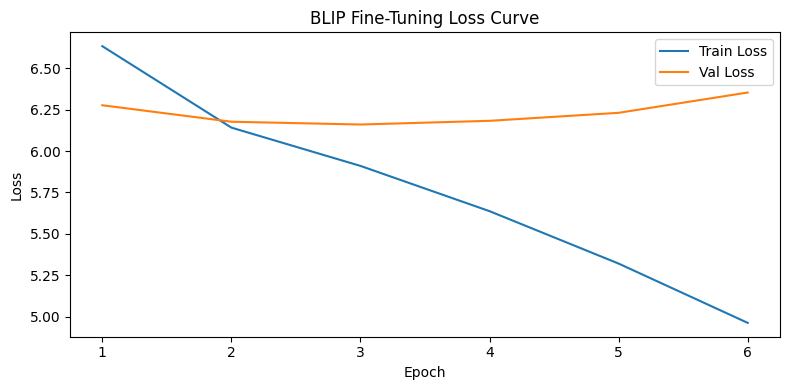

Loss curve saved!


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
plt.plot(history_df['epoch'], history_df['val_loss'],   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BLIP Fine-Tuning Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('blip_loss_curve.png', dpi=150)
plt.show()
print('Loss curve saved!')

## 14. Evaluate Fine-Tuned Model

In [15]:
# Load best checkpoint
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

print('Running fine-tuned evaluation on validation set...')
finetuned_preds, finetuned_refs = run_zero_shot(
    val_roco, processor, model, device
)

metrics_finetuned = compute_captioning_metrics(finetuned_preds, finetuned_refs)
print_captioning_metrics(metrics_finetuned, model_name='BLIP Fine-Tuned (Frozen Vision)')

Running fine-tuned evaluation on validation set...
  [0/769] done
  [50/769] done
  [100/769] done
  [150/769] done
  [200/769] done
  [250/769] done
  [300/769] done
  [350/769] done
  [400/769] done
  [450/769] done
  [500/769] done
  [550/769] done
  [600/769] done
  [650/769] done
  [700/769] done
  [750/769] done
  BLIP Fine-Tuned (Frozen Vision) /n
  BLEU   : 0.0000
  ROUGE-1: 0.0953
  ROUGE-2: 0.0097
  ROUGE-L: 0.0873


## 15. Results Comparison Table

In [17]:
# hardcoded metrics from zero-shot

# Hardcoded zero-shot results from earlier run
metrics_zeroshot = {
    'bleu':   0.0000,
    'rouge1': 0.0518,
    'rouge2': 0.0034,
    'rougeL': 0.0427,
}

results = pd.DataFrame([
    {'Model': 'BLIP Zero-Shot',                 **metrics_zeroshot},
    {'Model': 'BLIP Fine-Tuned (Frozen Vision)', **metrics_finetuned},
])

print(results.to_string(index=False))
results.to_csv('blip_results.csv', index=False)
print('\nResults saved to blip_results.csv')

                          Model  bleu  rouge1  rouge2  rougeL
                 BLIP Zero-Shot   0.0  0.0518  0.0034  0.0427
BLIP Fine-Tuned (Frozen Vision)   0.0  0.0953  0.0097  0.0873

Results saved to blip_results.csv


## 16. Qualitative Sample Predictions

  [0/5] done


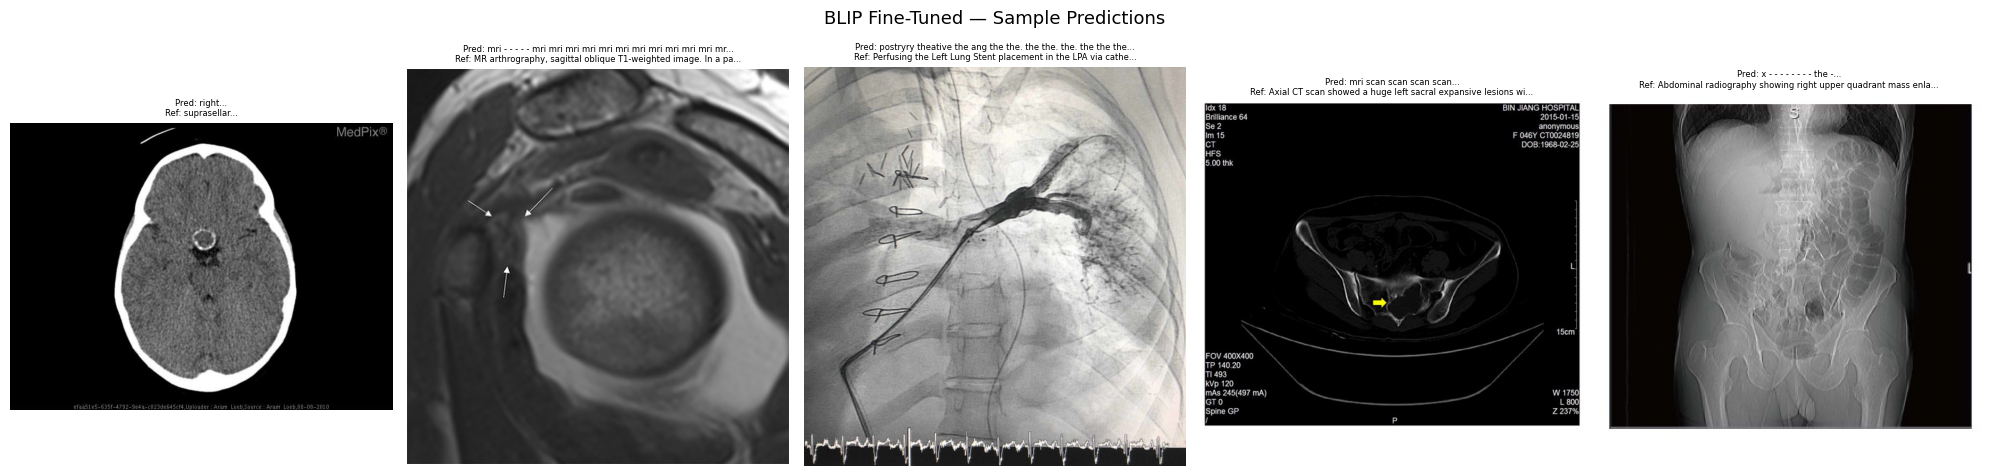

Sample predictions saved!


In [22]:
# Show 5 side-by-side predictions vs references
sample_df = val_roco.sample(5, random_state=RANDOM_STATE).reset_index(drop=True)
sample_preds_ft, sample_refs_ft = run_zero_shot(sample_df, processor, model, device)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('BLIP Fine-Tuned — Sample Predictions', fontsize=13)

for i, ax in enumerate(axes):
    img = open_image_from_dataset_value(sample_df.iloc[i]['image'])
    ax.imshow(img.convert('RGB'))
    ax.axis('off')
    title = f"Pred: {sample_preds_ft[i][:60]}...\nRef: {sample_refs_ft[i][:60]}..."
    ax.set_title(title, fontsize=6, wrap=True)

plt.tight_layout()
plt.savefig('blip_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample predictions saved!')

In [23]:
# Print full text comparison for report
print('\n=== Sample Predictions vs References ===\n')
for i, (pred, ref) in enumerate(zip(sample_preds_ft, sample_refs_ft)):
    print(f'--- Sample {i+1} ---')
    print(f'Question:  {sample_df.iloc[i]["question"]}')
    print(f'Generated: {pred}')
    print(f'Reference: {ref}')
    print()


=== Sample Predictions vs References ===

--- Sample 1 ---
Question:  where is the mass located?
Generated: right
Reference: suprasellar

--- Sample 2 ---
Question:  Describe the medical findings in this image.
Generated: mri - - - - - mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri mri the
Reference: MR arthrography, sagittal oblique T1-weighted image. In a patient with adhesive capsulitis for 15 weeks, the fat triangle (arrowheads) signal is considerably reduced

--- Sample 3 ---
Question:  Describe the medical findings in this image.
Generated: postryry theative the ang the the. the the. the. the the the the the. the the. the. the the
Reference: Perfusing the Left Lun

## 17. Save Final Predictions

In [ ]:
final_df = pd.DataFrame({
    'question':  val_roco['question'].tolist(),
    'reference': finetuned_refs,
    'finetuned': finetuned_preds,
})

final_df.to_csv('blip_all_predictions.csv', index=False)
print('All predictions saved to blip_all_predictions.csv')